In [2]:
import sqlite3

conn = sqlite3.connect('sale_data.db')
cursor = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        date TEXT,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
''')

data = [
    (1, '2025-04-01', 'Pen', 10, 5),
    (2, '2025-04-01', 'Pencil', 20, 3),
    (3, '2025-04-02', 'Notebook', 5, 20),
    (4, '2025-04-02', 'Eraser', 15, 2),
    (5, '2025-04-03', 'Pen', 5, 5),
    (6, '2025-04-03', 'Pencil', 10, 3),
]

cursor.executemany('INSERT INTO sales VALUES (?, ?, ?, ?, ?)', data)
conn.commit()
conn.close()

Sales Summary:
     product  total_qty  revenue
0    Eraser         15     30.0
1  Notebook          5    100.0
2       Pen         15     75.0
3    Pencil         30     90.0


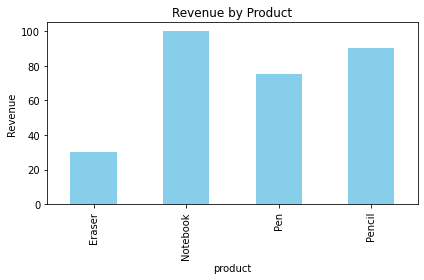

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect('sale_data.db')


query = '''
    SELECT 
        product, 
        SUM(quantity) AS total_qty, 
        SUM(quantity * price) AS revenue 
    FROM sales 
    GROUP BY product
'''

df = pd.read_sql_query(query, conn)
conn.close()

print("Sales Summary:\n", df)

df.plot(kind='bar', x='product', y='revenue', color='skyblue', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sale_chart.png")
plt.show()

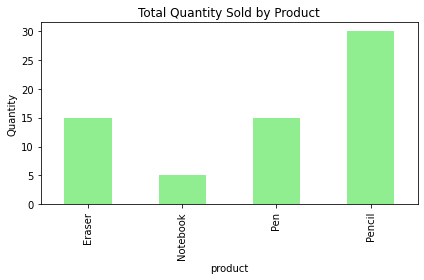

In [4]:
df.plot(kind='bar', x='product', y='total_qty', color='lightgreen', legend=False)
plt.title("Total Quantity Sold by Product")
plt.ylabel("Quantity")
plt.tight_layout()
plt.savefig("total_quantity_chart.png")
plt.show()

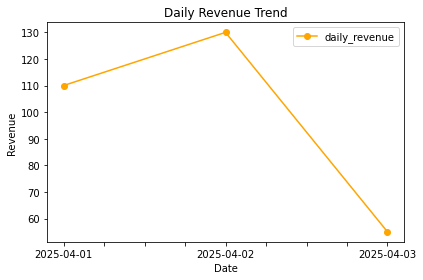

In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("sales_data.db")

query_daily = '''
    SELECT 
        date, 
        SUM(quantity * price) AS daily_revenue 
    FROM sales 
    GROUP BY date
    ORDER BY date
'''
df_daily = pd.read_sql_query(query_daily, conn)

conn.close()

# Plot
df_daily.plot(kind='line', x='date', y='daily_revenue', marker='o', color='orange')
plt.title("Daily Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("daily_revenue_chart.png")
plt.show()

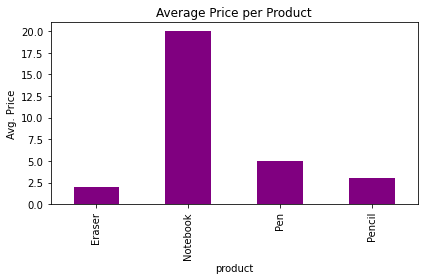

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("sales_data.db")

query_avg_price = '''
    SELECT 
        product, 
        ROUND(AVG(price), 2) AS avg_price 
    FROM sales 
    GROUP BY product
'''

df_avg_price = pd.read_sql_query(query_avg_price, conn)

# Plot average price bar
df_avg_price.plot(kind='bar', x='product', y='avg_price', color='purple', legend=False)
plt.title("Average Price per Product")
plt.ylabel("Avg. Price")
plt.tight_layout()
plt.savefig("avg_price_chart.png")
plt.show()